In [1]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ---------- 데이터 로드 & 그룹 정의 ----------
df = pd.read_csv("FDA_adverse_events_final.csv", low_memory=False)
s = df[df["WHO_ATC"] == "S"]
tears_terms = "SYSTANE|CARBOXYMETHYLCELLULOSE|HYPROMELLOSE|DEXTRAN|LUBRICANT"
mask = (
    s["suspect_drug"].str.contains(tears_terms, case=False, na=False)
    | s["brand_name"].str.contains(tears_terms, case=False, na=False)
)
sub = df.loc[s[mask].index].copy()
N = len(sub)



전체 N=25
제품 분포:
 product_group
CMC 계열\n(Refresh 등)        13
Systane\n(Hypromellose)     9
Dextran+\nHypromellose      2
Hypromellose\n단독            1
Name: count, dtype: int64

연령대:
 age_group
Middle-Aged(41-65)     1
Senior(66-80)          8
Elderly(81+)           2
Unknown               14
Name: count, dtype: int64

성별:
 patient_sex
Female     19
Male        2
Unknown     4
Name: count, dtype: int64

심각도:
 serious
Yes    13
No     12
Name: count, dtype: int64


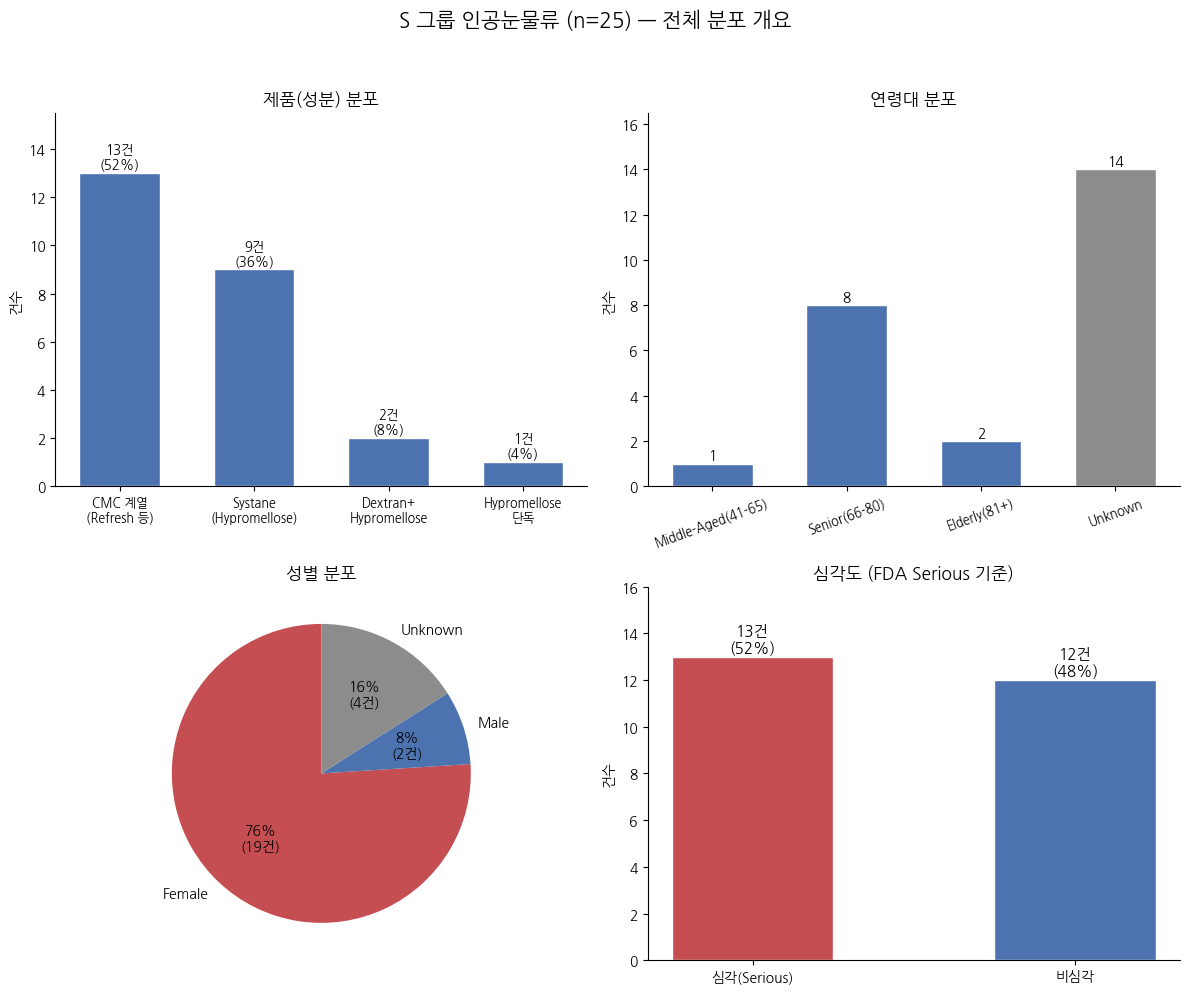

In [2]:
# ---------- 색상 컨벤션 ----------
COLOR_MAIN = "#4C72B0"
COLOR_SIGNAL = "#C44E52"
COLOR_NEUTRAL = "#8C8C8C"

# ---------- 제품(성분) 그룹 단순화 ----------
def product_group(row):
    drug = str(row["suspect_drug"])
    if "SYSTANE" in drug.upper():
        return "Systane\n(Hypromellose)"
    elif "CARBOXYMETHYLCELLULOSE" in drug.upper():
        return "CMC 계열\n(Refresh 등)"
    elif "DEXTRAN" in drug.upper():
        return "Dextran+\nHypromellose"
    elif "HYPROMELLOSE" in drug.upper():
        return "Hypromellose\n단독"
    else:
        return "기타"

sub["product_group"] = sub.apply(product_group, axis=1)

# ==================================================================
# Figure: 2x2
# ==================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f"S 그룹 인공눈물류 (n={N}) — 전체 분포 개요", fontsize=15, fontweight="bold", y=0.99)

# ---------- (1) 제품(성분) 분포 ----------
ax = axes[0, 0]
prod_counts = sub["product_group"].value_counts()
bars = ax.bar(prod_counts.index, prod_counts.values, color=COLOR_MAIN, edgecolor="white", width=0.6)
for b, v in zip(bars, prod_counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.2, f"{v}건\n({v/N*100:.0f}%)", ha="center", fontsize=9.5, fontweight="bold")
ax.set_title("제품(성분) 분포", fontsize=12.5, fontweight="bold")
ax.set_ylabel("건수")
ax.tick_params(axis="x", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, prod_counts.max() + 2.5)

# ---------- (2) 연령대 분포 ----------
ax = axes[0, 1]
age_order = ["Middle-Aged(41-65)", "Senior(66-80)", "Elderly(81+)", "Unknown"]
age_counts = sub["age_group"].value_counts().reindex(age_order, fill_value=0)
colors_age = [COLOR_NEUTRAL if a == "Unknown" else COLOR_MAIN for a in age_counts.index]
bars = ax.bar(age_counts.index, age_counts.values, color=colors_age, edgecolor="white", width=0.6)
for b, v in zip(bars, age_counts.values):
    if v > 0:
        ax.text(b.get_x() + b.get_width()/2, v + 0.2, str(v), ha="center", fontsize=10, fontweight="bold")
ax.set_title("연령대 분포", fontsize=12.5, fontweight="bold")
ax.set_ylabel("건수")
ax.tick_params(axis="x", rotation=20, labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, age_counts.max() + 2.5)

# ---------- (3) 성별 분포 ----------
ax = axes[1, 0]
sex_order = ["Female", "Male", "Unknown"]
sex_counts = sub["patient_sex"].value_counts().reindex(sex_order, fill_value=0)
colors_sex = [COLOR_SIGNAL, COLOR_MAIN, COLOR_NEUTRAL]
wedges, texts, autotexts = ax.pie(
    sex_counts.values, labels=sex_counts.index, colors=colors_sex,
    autopct=lambda p: f"{p:.0f}%\n({int(round(p*N/100))}건)" if p > 0 else "",
    startangle=90, textprops={"fontsize": 10}
)
ax.set_title("성별 분포", fontsize=12.5, fontweight="bold")

# ---------- (4) 심각도 분포 ----------
ax = axes[1, 1]
serious_counts = sub["serious"].value_counts().reindex(["Yes", "No"], fill_value=0)
bars = ax.bar(["심각(Serious)", "비심각"], serious_counts.values,
              color=[COLOR_SIGNAL, COLOR_MAIN], edgecolor="white", width=0.5)
for b, v in zip(bars, serious_counts.values):
    pct = v / N * 100
    ax.text(b.get_x() + b.get_width()/2, v + 0.2, f"{v}건\n({pct:.0f}%)", ha="center", fontsize=11, fontweight="bold")
ax.set_title("심각도 (FDA Serious 기준)", fontsize=12.5, fontweight="bold")
ax.set_ylabel("건수")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, serious_counts.max() + 3)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# ---------- 콘솔 요약 ----------
print(f"\n전체 N={N}")
print("제품 분포:\n", prod_counts)
print("\n연령대:\n", age_counts)
print("\n성별:\n", sex_counts)
print("\n심각도:\n", serious_counts)


전체 N=25
반응별 언급 횟수:
 reactions
Drug ineffective         9
Eye pain                 4
Eye irritation           3
Hypersensitivity         2
Ocular hyperaemia        2
Dry eye                  2
Lacrimation increased    2
Ocular discomfort        1
Erythema                 1
Erythema of eyelid       1
Eyelid irritation        1
Name: count, dtype: int64

케이스 분류:
 case_category
순수 국소반응만    9
국소+전신 혼재    8
해당없음        8
Name: count, dtype: int64


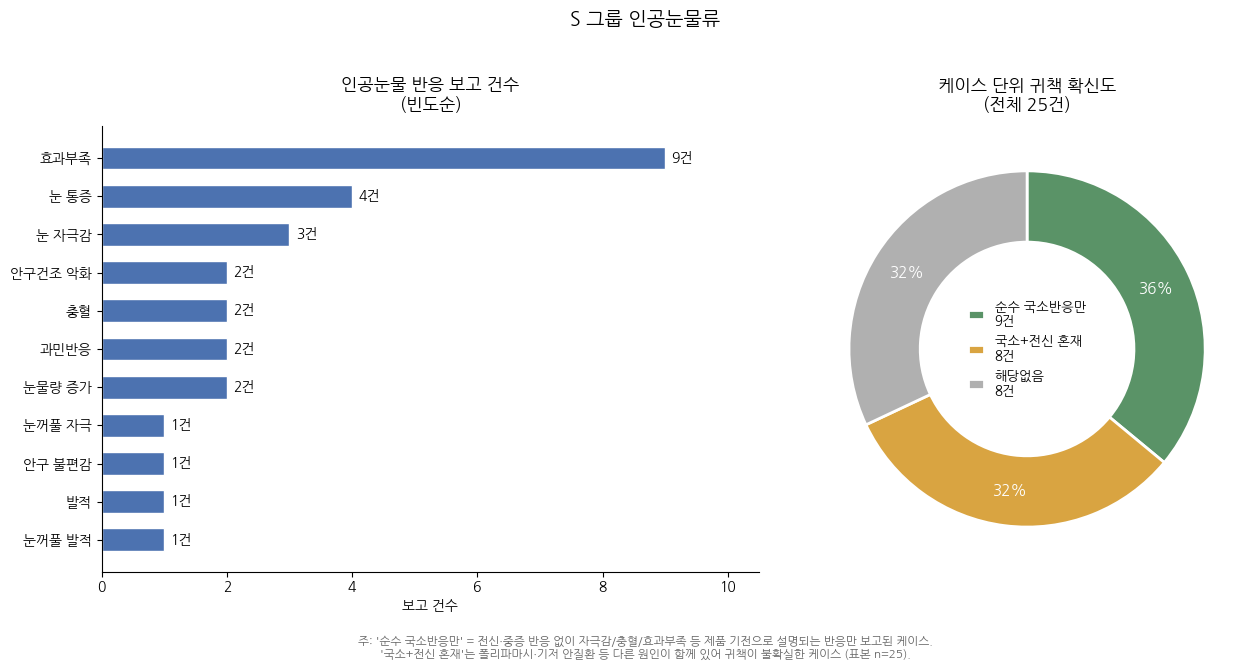

In [3]:
# ---------- 색상 컨벤션 ----------
COLOR_MAIN = "#4C72B0"     # 제품 귀책 개연성 반응 (blue - 국소/경미 톤)
COLOR_HIGH_CONF = "#5A9367"  # 순수 국소반응만 있는 케이스 (green)
COLOR_MIXED = "#D9A441"      # 국소+전신 혼재 (yellow)
COLOR_NONE = "#B0B0B0"       # 해당 반응 없음 (grey)

# ---------- 제품 귀책 개연성 높은 반응 목록 ----------
PRODUCT_ATTRIBUTABLE = {
    "Eye irritation", "Ocular hyperaemia", "Lacrimation increased", "Lacrimation decreased",
    "Eyelid irritation", "Erythema of eyelid", "Hypersensitivity", "Drug ineffective",
    "Dry eye", "Ocular discomfort", "Erythema", "Eye pain",
}

REACTION_LABELS_KR = {
    "Drug ineffective": "효과부족",
    "Eye pain": "눈 통증",
    "Eye irritation": "눈 자극감",
    "Hypersensitivity": "과민반응",
    "Dry eye": "안구건조 악화",
    "Ocular hyperaemia": "충혈",
    "Lacrimation increased": "눈물량 증가",
    "Eyelid irritation": "눈꺼풀 자극",
    "Erythema of eyelid": "눈꺼풀 발적",
    "Ocular discomfort": "안구 불편감",
    "Erythema": "발적",
}

exploded = sub["reactions"].dropna().str.split(";").apply(lambda l: [x.strip() for x in l]).explode()
counts = exploded.value_counts()
attrib_counts = counts[counts.index.isin(PRODUCT_ATTRIBUTABLE)].sort_values(ascending=True)

# ---------- 케이스 단위 분류 ----------
def case_category(reactions_str):
    if pd.isna(reactions_str):
        return "해당없음"
    items = {x.strip() for x in reactions_str.split(";")}
    has_attrib = bool(items & PRODUCT_ATTRIBUTABLE)
    has_other = bool(items - PRODUCT_ATTRIBUTABLE)
    if has_attrib and not has_other:
        return "순수 국소반응만"
    elif has_attrib and has_other:
        return "국소+전신 혼재"
    else:
        return "해당없음"

sub["case_category"] = sub["reactions"].apply(case_category)
cat_order = ["순수 국소반응만", "국소+전신 혼재", "해당없음"]
cat_colors = {"순수 국소반응만": COLOR_HIGH_CONF, "국소+전신 혼재": COLOR_MIXED, "해당없음": COLOR_NONE}
cat_counts = sub["case_category"].value_counts().reindex(cat_order, fill_value=0)

print(f"전체 N={N}")
print("반응별 언급 횟수:\n", attrib_counts.sort_values(ascending=False))
print("\n케이스 분류:\n", cat_counts)

# ==================================================================
# Figure: 좌측 랭킹 바 / 우측 케이스 분류 도넛
# ==================================================================
fig, (ax_bar, ax_donut) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={"width_ratios": [1.3, 1]})

# ---------- 좌측: 반응별 빈도 랭킹 ----------
labels_kr = [REACTION_LABELS_KR.get(r, r) for r in attrib_counts.index]
bars = ax_bar.barh(labels_kr, attrib_counts.values, color=COLOR_MAIN, edgecolor="white", height=0.6)
for bar, v in zip(bars, attrib_counts.values):
    ax_bar.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f"{v}건",
                va="center", fontsize=10, fontweight="bold")
ax_bar.set_xlabel("보고 건수", fontsize=10)
ax_bar.set_title("인공눈물 반응 보고 건수\n(빈도순)", fontsize=12.5, fontweight="bold", pad=12)
ax_bar.spines[["top", "right"]].set_visible(False)
ax_bar.set_xlim(0, attrib_counts.max() + 1.5)

# ---------- 우측: 케이스 단위 귀책 확신도 분류 ----------
wedges, texts, autotexts = ax_donut.pie(
    cat_counts.values, colors=[cat_colors[c] for c in cat_order], startangle=90, counterclock=False,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2),
    autopct=lambda p: f"{p:.0f}%" if p > 0 else "", pctdistance=0.8,
    textprops={"fontsize": 11, "fontweight": "bold", "color": "white"}
)
legend_labels = [f"{c}\n{cat_counts[c]}건" for c in cat_order]
ax_donut.legend(wedges, legend_labels, loc="center", bbox_to_anchor=(0.5, 0.5),
                 frameon=False, fontsize=9.5, handlelength=1.2)
ax_donut.set_title(f"케이스 단위 귀책 확신도\n(전체 {N}건)", fontsize=12.5, fontweight="bold", pad=12)

fig.suptitle("S 그룹 인공눈물류",
             fontsize=14, fontweight="bold", y=1.03)
fig.text(0.5, -0.05,
         "주: '순수 국소반응만' = 전신·중증 반응 없이 자극감/충혈/효과부족 등 제품 기전으로 설명되는 반응만 보고된 케이스.\n"
         "'국소+전신 혼재'는 폴리파마시·기저 안질환 등 다른 원인이 함께 있어 귀책이 불확실한 케이스 (표본 n=25).",
         ha="center", fontsize=8.5, color="#666666")

plt.tight_layout()


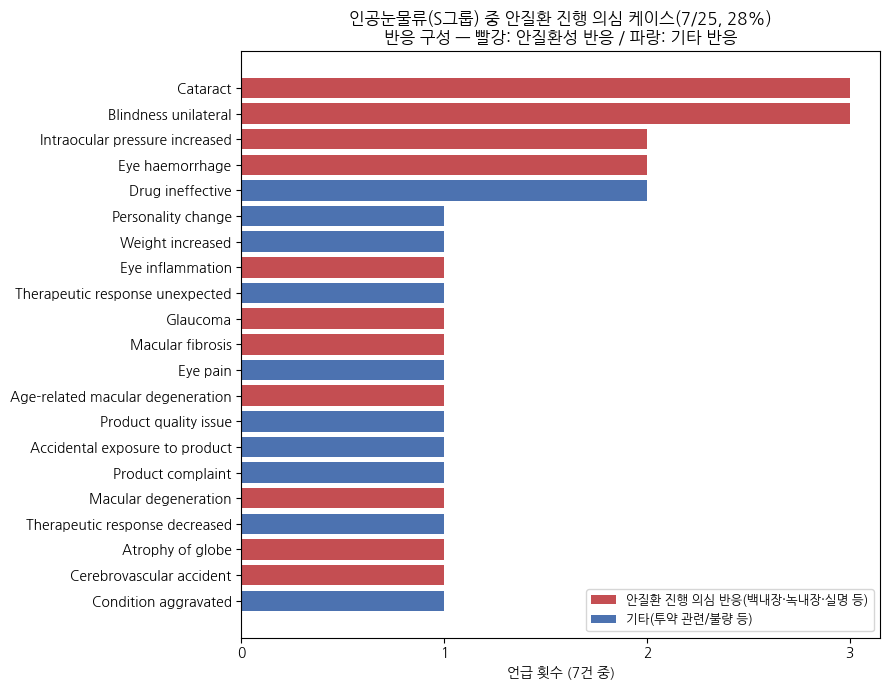

안질환 진행 의심 케이스: 7건 / 25건 (28%)
→ 백내장·실명·녹내장·황반변성·안구위축·뇌졸중 등, 인공눈물(윤활점안액) 자체 기전으로 설명하기 어려운 반응들


In [4]:
FOCAL = '#C44E52'   # 안질환성 반응 강조색
BASE  = '#4C72B0'   # 기타 반응 baseline색

# ── 7건 케이스의 반응 목록 (재현 가능하도록 raw 데이터 직접 기재) ──
confound_reactions_raw = [
    "Personality change; Weight increased; Intraocular pressure increased; Eye inflammation; Eye haemorrhage",
    "Therapeutic response unexpected; Glaucoma; Cataract; Blindness unilateral; Intraocular pressure increased",
    "Drug ineffective; Macular fibrosis; Eye pain; Blindness unilateral; Age-related macular degeneration",
    "Cataract; Product quality issue",
    "Accidental exposure to product; Product complaint; Cataract",
    "Macular degeneration; Drug ineffective; Therapeutic response decreased",
    "Atrophy of globe; Cerebrovascular accident; Blindness unilateral; Eye haemorrhage; Condition aggravated",
]

# 실제 '안질환 진행'으로 볼 수 있는 반응 vs 그 외(투약 관련/기타) 구분
disease_terms = {
    "Cataract", "Blindness unilateral", "Intraocular pressure increased",
    "Eye haemorrhage", "Glaucoma", "Macular fibrosis",
    "Age-related macular degeneration", "Macular degeneration",
    "Atrophy of globe", "Cerebrovascular accident", "Eye inflammation"
}

counter = Counter()
for r in confound_reactions_raw:
    for term in r.split(";"):
        counter[term.strip()] += 1

items = counter.most_common()
labels = [k for k, v in items]
values = [v for k, v in items]
colors = [FOCAL if k in disease_terms else BASE for k in labels]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(labels[::-1], values[::-1], color=colors[::-1])

ax.set_xlabel("언급 횟수 (7건 중)")
ax.set_title("인공눈물류(S그룹) 중 안질환 진행 의심 케이스(7/25, 28%)\n반응 구성 — 빨강: 안질환성 반응 / 파랑: 기타 반응", fontsize=12)
ax.set_xticks(range(0, max(values)+1))

# 범례
legend_elements = [
    mpatches.Patch(facecolor=FOCAL, label='안질환 진행 의심 반응(백내장·녹내장·실명 등)'),
    mpatches.Patch(facecolor=BASE, label='기타(투약 관련/불량 등)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print(f"안질환 진행 의심 케이스: 7건 / 25건 (28%)")
print(f"→ 백내장·실명·녹내장·황반변성·안구위축·뇌졸중 등, 인공눈물(윤활점안액) 자체 기전으로 설명하기 어려운 반응들")


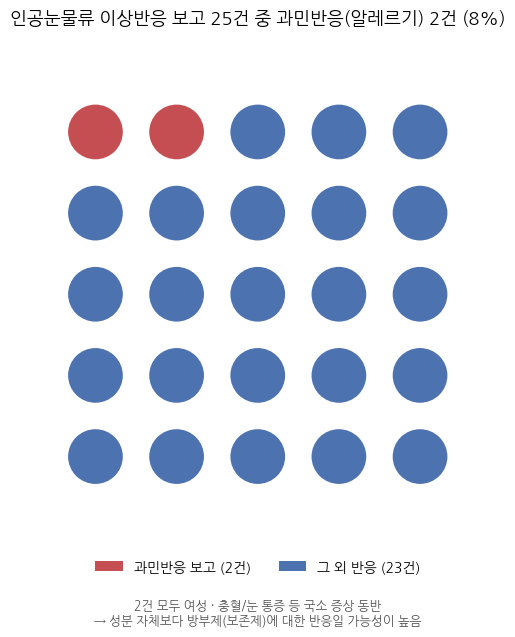

In [5]:
FOCAL = '#C44E52'   # 과민반응 케이스
BASE  = '#4C72B0'   # 그 외 케이스

n_total = 25
n_hypersensitivity = 2

fig, ax = plt.subplots(figsize=(8, 6))

# 5x5 그리드로 25건을 아이콘(원)으로 배치
rows, cols = 5, 5
positions = [(c, r) for r in range(rows) for c in range(cols)]

for i, (x, y) in enumerate(positions):
    color = FOCAL if i < n_hypersensitivity else BASE
    circle = plt.Circle((x, -y), 0.35, color=color, ec='white', linewidth=1.5, zorder=2)
    ax.add_patch(circle)

ax.set_xlim(-1, cols)
ax.set_ylim(-rows, 1)
ax.set_aspect('equal')
ax.axis('off')

ax.set_title(
    f"인공눈물류 이상반응 보고 {n_total}건 중 과민반응(알레르기) {n_hypersensitivity}건 (8%)",
    fontsize=13, pad=20
)

# 범례
legend_elements = [
    mpatches.Patch(facecolor=FOCAL, label=f'과민반응 보고 ({n_hypersensitivity}건)'),
    mpatches.Patch(facecolor=BASE, label=f'그 외 반응 ({n_total - n_hypersensitivity}건)')
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02),
          ncol=2, fontsize=10, frameon=False)

# 하단 설명 텍스트
fig.text(0.5, -0.05,
         "2건 모두 여성 · 충혈/눈 통증 등 국소 증상 동반\n"
         "→ 성분 자체보다 방부제(보존제)에 대한 반응일 가능성이 높음",
         ha='center', fontsize=9, color='#555555')

plt.tight_layout()
plt.show()
